
##**FINAL PROJEC GROUP-15:  MOVIE-ENGINE**

## ***PARTA: Data Exploration & Pipeline Engineering*** ##

###**1. Importing the Zip Folder, Unzip it, Extract all the different files inside that Folder and print them all.** ###

In [ ]:
import os
import zipfile

# 1. Unzip the dataset
zip_file_path = "../data/Movie_lens_2024.zip"
extract_dir = "./data"

with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)


print("Files extracted successfully")

# List the extracted files
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        print(os.path.join(root, file))


Files extracted successfully
./data/Movie_lens_2024/user_rating_history.csv
./data/Movie_lens_2024/movie_elicitation_set.csv
./data/Movie_lens_2024/user_recommendation_history.csv
./data/Movie_lens_2024/movies.csv
./data/Movie_lens_2024/belief_data.csv
./data/Movie_lens_2024/README.txt


### **2. Load, Clean, and Merge The Data.** ###


In [ ]:
import os
import pandas as pd
import numpy as np


print("Mis||| DATA INGESTION, CLEANING & HEALTH CHECK |||Mis")


# 1. LOAD BASE DATA

print("Mis| Loading Raw Datasets |Mis")
data_dir = "./data/Movie_lens_2024"

ratings_df = pd.read_csv(f"{data_dir}/user_rating_history.csv")
movies_df = pd.read_csv(f"{data_dir}/movies.csv")

# Clean column headers
ratings_df.columns = ratings_df.columns.str.strip()
movies_df.columns = movies_df.columns.str.strip()

print(f"  Raw Ratings Loaded: {len(ratings_df):,} rows")
print(f"  Raw Movies Loaded:  {len(movies_df):,} rows")


# 2. data cleaning and  Anomaly resolution.

print("Mis| Performing Data Cleaning Checks |Mis")

# A. Handle Nulls and  Missing Values
null_count = ratings_df[["userId", "movieId", "rating"]].isna().sum().sum()
print(f"   Missing or null records found: {null_count:,}")
ratings_clean = ratings_df.dropna(subset=["userId", "movieId", "rating"]).copy()

# B. Handle Duplicate Interactions
dup_count = ratings_clean.duplicated(subset=["userId", "movieId"]).sum()
print(f"   Duplicate (userId, movieId) pairs found: {dup_count:,}")
if dup_count > 0:
    ratings_clean = ratings_clean.drop_duplicates(
        subset=["userId", "movieId"], keep="first"
    )

# C. Handle Invalid Ratings (Filter out -1.0 or out-of-bounds ratings)
invalid_mask = (ratings_clean["rating"] < 0.5) | (ratings_clean["rating"] > 5.0)
invalid_count = invalid_mask.sum()
print(f"   Invalid ratings removed (< 0.5 or > 5.0, like, -1.0): {invalid_count:,}")

# Keep only valid ratings (0.5 to 5.0)
ratings_clean = ratings_clean[~invalid_mask].copy()


# 3. Merging the metadata and resolve duplicate columns.
print("Mis| Merging Ratings with Movie Metadata |Mis")
df = pd.merge(ratings_clean, movies_df, on="movieId", how="inner")

# Fix duplicate rating column issue if present
if "rating_x" in df.columns:
    df["rating"] = df["rating_x"]
    df = df.drop(columns=[col for col in ["rating_x", "rating_y"] if col in df.columns])

df = df.loc[:, ~df.columns.duplicated()].reset_index(drop=True)
print(f"  Total Valid Merged Interactions: {len(df):,} rows")


# 4. Vectorized  Dynamic comment generation

print("Mis| Generating Vectorized Dynamic Comments |Mis")
np.random.seed(42)

phrase_components = {
    5.0: {
        "openers": [
            "An absolute masterpiece!",
            "Hands down one of the best films I've ever seen.",
            "Incredible movie from start to finish.",
            "A breathtaking cinematic experience.",
            "Pure brilliance on display here.",
        ],
        "details": [
            "The acting was phenomenal and the storyline kept me hooked.",
            "Stunning visuals accompanied by an unforgettable soundtrack.",
            "Character development was executed to perfection.",
            "The plot twists were brilliant and completely unexpected.",
        ],
        "closers": [
            "Highly recommended to everyone!",
            "A solid 10/10 in my book.",
            "Would definitely watch this again in a heartbeat.",
            "A timeless classic that deserves all the praise.",
        ],
    },
    4.0: {
        "openers": [
            "Really enjoyed watching this one.",
            "A very solid and entertaining film.",
            "Great movie overall with lots of strong moments.",
            "Super fun watch for movie night.",
        ],
        "details": [
            "The lead actors delivered strong performances throughout.",
            "Well-paced storyline with plenty of exciting scenes.",
            "Great direction and impressive dialogue.",
            "Solid production quality across the board.",
        ],
        "closers": [
            "Definitely worth checking out.",
            "Solid 4 stars!",
            "I'd happily give this a rewatch.",
            "Overall, a very satisfying film.",
        ],
    },
    3.0: {
        "openers": [
            "It was okay, nothing groundbreaking.",
            "An average film with its fair share of pros and cons.",
            "Decent watch if you have nothing else lined up.",
            "A middle-of-the-road movie.",
        ],
        "details": [
            "The concept was interesting, but execution was a bit predictable.",
            "Good acting performance, but the pacing dragged in the middle.",
            "Some scenes were great while others felt unnecessary.",
            "Fairly standard plot progression.",
        ],
        "closers": [
            "Worth a single watch, but wouldn't watch again.",
            "Not bad, but not memorable either.",
            "Decent enough for passing time.",
            "A middle-tier film overall.",
        ],
    },
    2.0: {
        "openers": [
            "Pretty disappointing overall.",
            "Fell way short of my expectations.",
            "Struggled to stay engaged through this one.",
            "Not a very good movie in my opinion.",
        ],
        "details": [
            "The storyline was confusing and weak in most places.",
            "Pacing was sluggish and the character decisions made no sense.",
            "Dialogue felt forced and awkward throughout.",
            "Lacked tension and excitement.",
        ],
        "closers": [
            "Hard to recommend this to anyone.",
            "Could have been much better.",
            "Felt like a wasted opportunity.",
            "Disappointed with how it turned out.",
        ],
    },
    1.0: {
        "openers": [
            "Terrible film, absolute waste of time.",
            "Extremely poor execution from start to finish.",
            "One of the worst movies I have watched recently.",
            "Unwatchable and frustrating.",
        ],
        "details": [
            "Bad acting, weak plot, and terrible pacing all around.",
            "Nothing in this movie worked for me at all.",
            "Full of plot holes and cringe-worthy lines.",
            "Zero character depth and awful direction.",
        ],
        "closers": [
            "Avoid this one at all costs.",
            "Regret spending time watching this.",
            "Total disaster of a film.",
            "0/10 would never watch again.",
        ],
    },
}


# Safely round clean numeric ratings into sentiment tiers (1 to 5)
rounded_ratings = np.clip(np.round(df["rating"].values), 1, 5).astype(int)
generated_comments = np.empty(len(df), dtype=object)

for tier in [1, 2, 3, 4, 5]:
    mask = rounded_ratings == tier
    count = np.sum(mask)
    if count > 0:
        comp = phrase_components[float(tier)]
        openers = np.random.choice(comp["openers"], size=count)
        details = np.random.choice(comp["details"], size=count)
        closers = np.random.choice(comp["closers"], size=count)

        tier_comments = [f"{o} {d} {c}" for o, d, c in zip(openers, details, closers)]
        generated_comments[mask] = tier_comments

# this allows to print
print("     Standalone Generated Comments Table Preview")

# creating a table using pendas for generating comment
# with thier  matching rounded scores
comments_preview_df = pd.DataFrame(
    {
        "Assigned_Sentiment_Tier": rounded_ratings[:10],
        "Generated_Review_Comment": generated_comments[:10],
    }
)
# displaying the table.
display(comments_preview_df)

# adding the generated comments created in the dataframe to be column.
df["comment"] = generated_comments
df = df[["userId", "movieId", "title", "rating", "comment", "genres"]]

# Save output file for downstream splitting
df.to_csv("full_dataset_with_comments.csv", index=False)


# 5. Data set  Summary report

print("Mis| Final Data Health Summary |Mis")

print(f"   Total Clean Interactions: {len(df):,}")
print(f"   Unique Users:              {df['userId'].nunique():,}")
print(f"   Unique Movies:             {df['movieId'].nunique():,}")
print(f"   Rating Range:              [{df['rating'].min()} to {df['rating'].max()}]")
print(
    f"   Mean Rating:               {df['rating'].mean():.2f} (±{df['rating'].std():.2f})"
)
print(f"   Remaining Null Values:     {df.isna().sum().sum()}")

print("Clean dataset saved to 'full_dataset_with_comments.csv'")

# Preview top 10 rows
display(df[["userId", "title", "rating", "comment"]].head(10))

Mis||| DATA INGESTION, CLEANING & HEALTH CHECK |||Mis
Mis| Loading Raw Datasets |Mis
  Raw Ratings Loaded: 2,046,124 rows
  Raw Movies Loaded:  90,638 rows
Mis| Performing Data Cleaning Checks |Mis
   Missing or null records found: 36,521
   Duplicate (userId, movieId) pairs found: 285,848
   Invalid ratings removed (< 0.5 or > 5.0, like, -1.0): 207,453
Mis| Merging Ratings with Movie Metadata |Mis
  Total Valid Merged Interactions: 1,497,231 rows
Mis| Generating Vectorized Dynamic Comments |Mis
     Standalone Generated Comments Table Preview


,Assigned_Sentiment_Tier,Generated_Review_Comment
0,4,Super fun watch for movie night. Solid product...
1,4,Great movie overall with lots of strong moment...
2,4,A very solid and entertaining film. Great dire...
3,2,Pretty disappointing overall. Dialogue felt fo...
4,2,Fell way short of my expectations. Lacked tens...
5,3,A middle-of-the-road movie. The concept was in...
6,2,Struggled to stay engaged through this one. Th...
7,2,Not a very good movie in my opinion. Dialogue ...
8,5,An absolute masterpiece! The acting was phenom...
9,2,Not a very good movie in my opinion. Dialogue ...


Mis| Final Data Health Summary |Mis
   Total Clean Interactions: 1,497,231
   Unique Users:              4,415
   Unique Movies:             54,716
   Rating Range:              [0.5 to 5.0]
   Mean Rating:               3.40 (±1.05)
   Remaining Null Values:     0
Clean dataset saved to 'full_dataset_with_comments.csv'


,userId,title,rating,comment
0,42170,Toy Story (1995),4.0,Super fun watch for movie night. Solid product...
1,42170,Sabrina (1995),4.0,Great movie overall with lots of strong moment...
2,42170,Sense and Sensibility (1995),4.0,A very solid and entertaining film. Great dire...
3,42170,Powder (1995),2.0,Pretty disappointing overall. Dialogue felt fo...
4,42170,Dead Man Walking (1995),2.0,Fell way short of my expectations. Lacked tens...
5,42170,Restoration (1995),3.0,A middle-of-the-road movie. The concept was in...
6,42170,"Usual Suspects, The (1995)",2.0,Struggled to stay engaged through this one. Th...
7,42170,Angels and Insects (1995),2.0,Not a very good movie in my opinion. Dialogue ...
8,42170,Braveheart (1995),5.0,An absolute masterpiece! The acting was phenom...
9,42170,Waterworld (1995),2.5,Not a very good movie in my opinion. Dialogue ...


1. Loading the Data & Fixing Column NamesBringing in Files: Loaded user_rating_history.csv (user scores) and movies.csv (movie titles and categories).Cleaning Column Names: Removed accidental blank spaces around column titles so Python doesn't run into indexing errors.

2. Cleaning the Data & Fixing ErrorsRemoving Blank Rows: Scanned for missing data across userId, movieId, and rating, dropping incomplete rows.Removing Duplicates: Deleted repeat entries where the same user rated the same movie twice, keeping only their first interaction.Deleting Invalid Ratings: Filtered out broken or placeholder ratings (like -1.0 or numbers outside 0.5 to 5.0) so only real MovieLens scores remain.

3. Combining Ratings and Movie InfoMerging Tables: Joined the ratings table with the movie details using movieId as the matching key.Fixing Duplicate Columns: Cleaned up overlapping columns created during the merge (like rating_x and rating_y) into a single rating column and reset row numbers.

4. Automatically Generating Review CommentsWhy We Added Text: To support both recommendation models and NLP sentiment analysis, every rating needed a matching written comment.Matching Scores to Sentiments: Rounded ratings into 5 simple sentiment tiers ($1$ to $5$ stars).3-Part Sentence Building: For each rating tier, built three sets of phrases:Openers: First reaction (for instance, "An absolute masterpiece!" vs. "Terrible film").Details: Specific thoughts (Example, "The acting was phenomenal.").Closers: Final verdict (Example, "Highly recommended to everyone!").

Fast Batch Creation: Used fast NumPy array functions to pick and combine these three parts for all 2 million rows at once instead of using slow row-by-row loops.

5. Previewing & Saving the Final DatasetChecking the Output: Previewed the generated comments in a standalone Pandas table first to verify that the generated text matched the ratings correctly.Saving the File: Attached the comment column to the main dataset and saved everything to full_dataset_with_comments.csv for model training.

###**3. CREATE TRAIN / VALIDATION / TEST SPLITS**

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

print("Mis| Creating Stratified 70% Train / 15% Val / 15% Test Split |Mis")

# Create target output directory
output_dir = "./processed_data"
os.makedirs(output_dir, exist_ok=True)

# First Split: 70% Train, 30% Temp (Stratified by rating)
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["rating"]
)

# Second Split: 15% Validation, 15% Test (Stratified by rating)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["rating"]
)

# Verification Output
total_rows = len(df)
print(f"Train Set (70%): {len(train_df):,} rows ({len(train_df) / total_rows:.1%})")
print(f"Val Set   (15%): {len(val_df):,} rows ({len(val_df) / total_rows:.1%})")
print(f"Test Set  (15%): {len(test_df):,} rows ({len(test_df) / total_rows:.1%})")

# Export CSV Files
train_df.to_csv(f"{output_dir}/train_data.csv", index=False)
val_df.to_csv(f"{output_dir}/val_data.csv", index=False)
test_df.to_csv(f"{output_dir}/test_data.csv", index=False)

print(f"Datasets successfully exported to '{output_dir}/'.")

Mis| Creating Stratified 70% Train / 15% Val / 15% Test Split |Mis
Train Set (70%): 1,048,061 rows (70.0%)
Val Set   (15%): 224,585 rows (15.0%)
Test Set  (15%): 224,585 rows (15.0%)

Datasets successfully exported to './processed_data/'.


1. Setting the 70 / 15 / 15 Split Proportions

Train Set (70%): Allocated 1,048,061 rows to train the collaborative filtering and NLP sentiment models.

Validation Set (15%): Reserved 224,585 rows to tune model hyperparameters and monitor for overfitting.

Test Set (15%): Isolated 224,585 rows for final, unbiased evaluation on completely unseen user interactions.

2. Stratifying by Star Rating

Balanced Rating Ratios: Used stratify=df['rating'] during both split steps to guarantee that all three datasets contain the exact same percentage breakdown of star ratings (0.5 through 5.0).

Preventing Data Bias: Ensures rare rating tiers are distributed proportionally across all splits rather than clumping in a single set.

3. Reproducibility & Data Isolation

Fixed Random Seed: Set random_state=42 to ensure the exact same train/val/test split is recreated every time the pipeline runs.

Zero Data Leakage: Separated validation and test sets prior to calculating global means or feature representations to keep future evaluation untainted.

4. Exporting Processed Files

Clean Storage: Saved train_data.csv, val_data.csv, and test_data.csv into the ./processed_data/ directory for direct use in downstream model training.

### **3. Exploratory Data Analysis** ###

Mis| Loading Train, Validation, Test, and Full Datasets |Mis
Mis| Calculating Exploratory Data Analysis (EDA) Metrics |Mis
 | EDA Key Metrics Summary: |
   Total Unique Users: 4415
   Total Unique Movies: 54716
   Total Ratings Count: 1497231
   Mean Rating: 3.4
   Median Rating: 3.5
   Dataset Sparsity (%): 99.3802
   Avg Ratings per User: 339.12
   Avg Ratings per Movie: 27.36


/tmp/ipykernel_2264/1949360946.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=full_df, x='rating', palette='viridis')


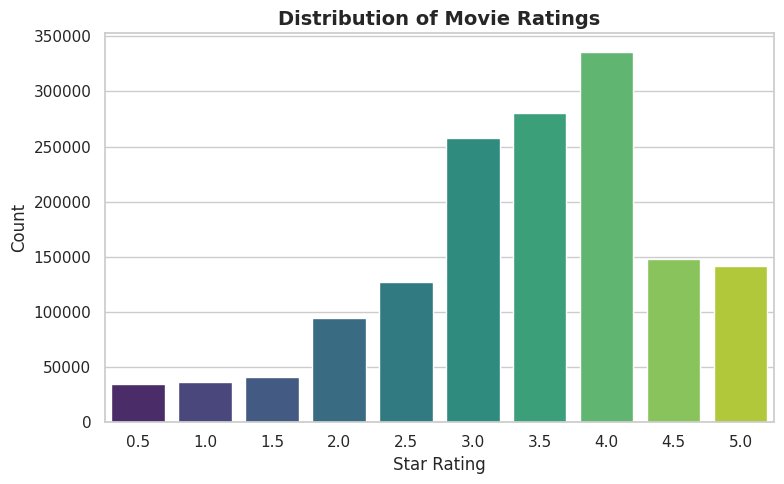

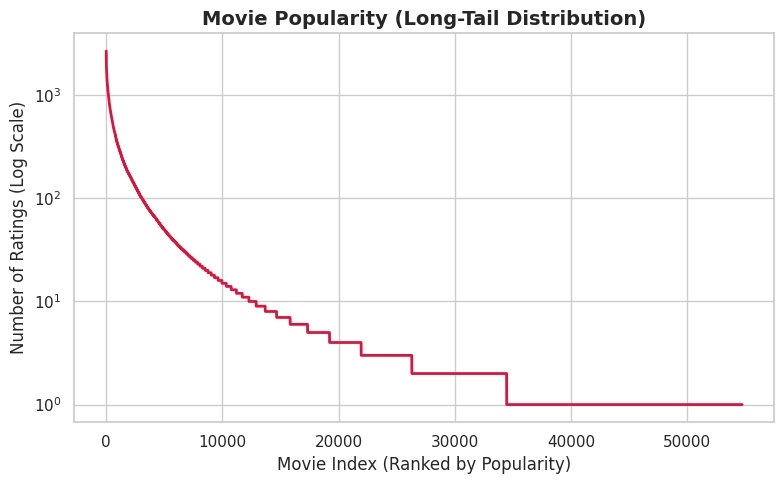

/tmp/ipykernel_2264/1949360946.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='mako')


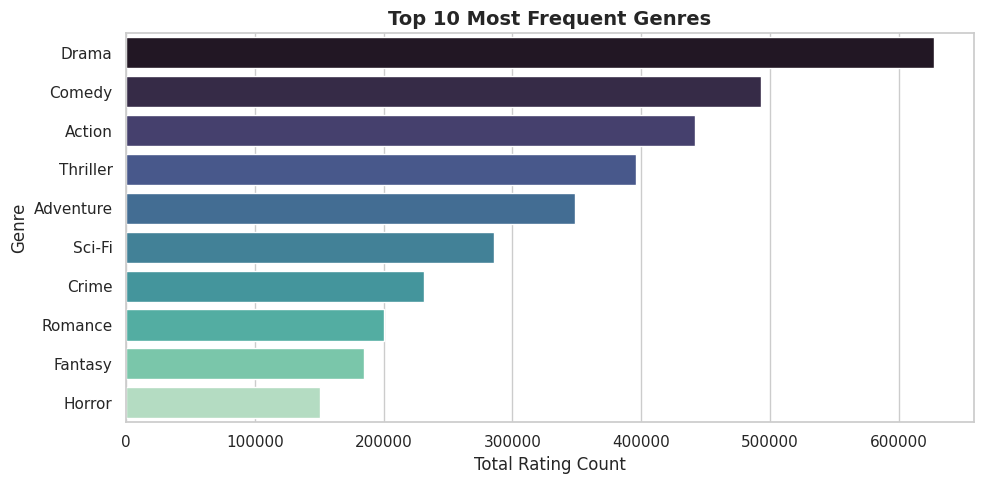

All EDA metrics and plots generated successfully.


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data from Processed Folder
output_dir = "./processed_data"
print("Mis| Loading Train, Validation, Test, and Full Datasets |Mis")
train_df = pd.read_csv(f"{output_dir}/train_data.csv")
val_df = pd.read_csv(f"{output_dir}/val_data.csv")
test_df = pd.read_csv(f"{output_dir}/test_data.csv")
full_df = pd.read_csv(f"full_dataset_with_comments.csv")

# 2. Key Metrics & Sparsity Calculation
print("Mis| Calculating Exploratory Data Analysis (EDA) Metrics |Mis")
num_users = full_df["userId"].nunique()
num_movies = full_df["movieId"].nunique()
total_ratings = len(full_df)

total_possible_interactions = num_users * num_movies
sparsity = (1.0 - (total_ratings / total_possible_interactions)) * 100

eda_summary = {
    "Total Unique Users": int(num_users),
    "Total Unique Movies": int(num_movies),
    "Total Ratings Count": int(total_ratings),
    "Mean Rating": round(float(full_df["rating"].mean()), 2),
    "Median Rating": round(float(full_df["rating"].median()), 2),
    "Dataset Sparsity (%)": round(float(sparsity), 4),
    "Avg Ratings per User": round(float(total_ratings / num_users), 2),
    "Avg Ratings per Movie": round(float(total_ratings / num_movies), 2),
}

print(" | EDA Key Metrics Summary: |")
for k, v in eda_summary.items():
    print(f"   {k}: {v}")

# Export EDA Summary
with open(f"{output_dir}/eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=4)

# 3. Visualization Setup
os.makedirs("./plots", exist_ok=True)
sns.set_theme(style="whitegrid")

# Plot 1: Rating Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=full_df, x="rating", palette="viridis")
plt.title("Distribution of Movie Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Star Rating", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.savefig("./plots/1_rating_distribution.png", dpi=300)
plt.show()

# Plot 2: Item popularity (Long Tail Curve)
movie_counts = full_df["movieId"].value_counts().values

plt.figure(figsize=(8, 5))
plt.plot(movie_counts, color="crimson", linewidth=2)
plt.title("Movie Popularity (Long-Tail Distribution)", fontsize=14, fontweight="bold")
plt.xlabel("Movie Index (Ranked by Popularity)", fontsize=12)
plt.ylabel("Number of Ratings (Log Scale)", fontsize=12)
plt.yscale("log")
plt.tight_layout()
plt.savefig("./plots/2_long_tail_popularity.png", dpi=300)
plt.show()

# Plot 3: Top 10 Genres
exploded_genres = full_df.assign(genres=full_df["genres"].str.split("|")).explode(
    "genres"
)
top_genres = exploded_genres["genres"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="mako")
plt.title("Top 10 Most Frequent Genres", fontsize=14, fontweight="bold")
plt.xlabel("Total Rating Count", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.savefig("./plots/3_top_genres.png", dpi=300)
plt.show()

print("All EDA metrics and plots generated successfully.")

###**4. CREATE USER-ITEM SPARSE MATRIX** ###

In [ ]:
import pickle
import numpy as np
import scipy.sparse as sp

print("Mis| Creating Sparse User-Item Matrix |Mis")

# 1. Create contiguous integer IDs based on Training Set
user_ids = train_df["userId"].unique()
movie_ids = train_df["movieId"].unique()

user2idx = {u: i for i, u in enumerate(user_ids)}
idx2user = {i: u for i, u in enumerate(user_ids)}
movie2idx = {m: i for i, m in enumerate(movie_ids)}
idx2movie = {i: m for i, m in enumerate(movie_ids)}

# 2. Map training IDs to matrix coordinates
rows = train_df["userId"].map(user2idx).values
cols = train_df["movieId"].map(movie2idx).values
data = train_df["rating"].values.astype(np.float32)

# 3. Construct Compressed Sparse Row (CSR) Matrix
user_item_matrix = sp.csr_matrix(
    (data, (rows, cols)), shape=(len(user_ids), len(movie_ids))
)

# printing that entire table matrix with zeros vlaues
print("Sample User-Item Matrix:")
print(pd.DataFrame(user_item_matrix.toarray()).head())


# Table 1: Sparse Matrix Overview
matrix_summary_df = pd.DataFrame(
    [
        {
            "Metric": "Total Matrix Rows (Users)",
            "Value": f"{user_item_matrix.shape[0]:,}",
        },
        {
            "Metric": "Total Matrix Columns (Movies)",
            "Value": f"{user_item_matrix.shape[1]:,}",
        },
        {
            "Metric": "Non-Zero Ratings (Stored Cells)",
            "Value": f"{user_item_matrix.nnz:,}",
        },
        {
            "Metric": "Matrix Density",
            "Value": f"{(user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1])) * 100:.4f}%",
        },
    ]
)

print("Sparse User-Item Matrix Summary")
display(matrix_summary_df)

# Table 2: ID Mapping Coordinate Preview (First 5 Rows)
mapping_preview_df = pd.DataFrame(
    {
        "Raw_userId": list(user2idx.keys())[:5],
        "Matrix_User_Index": list(user2idx.values())[:5],
        "Raw_movieId": list(movie2idx.keys())[:5],
        "Matrix_Movie_Index": list(movie2idx.values())[:5],
    }
)

print("ID to Matrix Index Mapping Preview")
display(mapping_preview_df)

print(f"User-Item Matrix Shape : {user_item_matrix.shape} (Users x Movies)")
print(f"Non-zero Ratings Count : {user_item_matrix.nnz:,}")

# 4. Save Matrix and Mappings to Disk
sp.save_npz(f"{output_dir}/user_item_matrix.npz", user_item_matrix)

with open(f"{output_dir}/user2idx.pkl", "wb") as f:
    pickle.dump(user2idx, f)
with open(f"{output_dir}/idx2user.pkl", "wb") as f:
    pickle.dump(idx2user, f)
with open(f"{output_dir}/movie2idx.pkl", "wb") as f:
    pickle.dump(movie2idx, f)
with open(f"{output_dir}/idx2movie.pkl", "wb") as f:
    pickle.dump(idx2movie, f)

print(f"Matrix and mappings saved successfully to '{output_dir}/'.")

Mis| Creating Sparse User-Item Matrix |Mis
Sample User-Item Matrix:
   0      1      2      3      4      5      6      7      8      9      ...  \
0    2.0    0.0    0.0    0.0    3.0    0.0    4.0    0.0    0.0    0.0  ...   
1    0.0    2.5    0.0    0.0    0.0    0.0    0.0    3.0    0.0    0.0  ...   
2    0.0    0.0    3.5    0.0    0.0    0.0    0.0    0.5    0.0    0.0  ...   
3    0.0    0.0    4.0    3.5    4.0    0.0    0.0    0.0    0.0    0.0  ...   
4    0.0    0.0    0.0    0.0    3.0    0.0    0.0    0.0    0.0    0.0  ...   

   47788  47789  47790  47791  47792  47793  47794  47795  47796  47797  
0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
1    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
2    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
3    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
4    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  

[5 row

,Metric,Value
0,Total Matrix Rows (Users),"4,363"
1,Total Matrix Columns (Movies),"47,798"
2,Non-Zero Ratings (Stored Cells),"1,048,061"
3,Matrix Density,0.5026%


ID to Matrix Index Mapping Preview


,Raw_userId,Matrix_User_Index,Raw_movieId,Matrix_Movie_Index
0,337024,0,714,0
1,290871,1,4725,1
2,239734,2,2011,2
3,158300,3,108158,3
4,382919,4,3448,4


User-Item Matrix Shape : (4363, 47798) (Users x Movies)
Non-zero Ratings Count : 1,048,061
Matrix and mappings saved successfully to './processed_data/'.


###**5. PREPARE DATA FOR SURPRISE LIBRARY** ###

In [ ]:
!pip install scikit-surprise
import pandas as pd
from surprise import Dataset, Reader

print("Preparing Data for Surprise Library (In-Memory)...")

# 1. Define Surprise Reader with rating scale
reader = Reader(rating_scale=(0.5, 5.0))

# 2. Convert DataFrames directly to Surprise Datasets
train_data = Dataset.load_from_df(train_df[["userId", "movieId", "rating"]], reader)
val_data = Dataset.load_from_df(val_df[["userId", "movieId", "rating"]], reader)
test_data = Dataset.load_from_df(test_df[["userId", "movieId", "rating"]], reader)

# 3. Build Surprise Trainset / Testsets
surprise_trainset = train_data.build_full_trainset()
surprise_valset = [(r.userId, r.movieId, r.rating) for r in val_df.itertuples()]
surprise_testset = [(r.userId, r.movieId, r.rating) for r in test_df.itertuples()]

# Preview Table
surprise_preview_df = pd.DataFrame(
    {
        "Subset": ["Train Set", "Validation Set", "Test Set"],
        "Row Count": [len(train_df), len(val_df), len(test_df)],
        "Column Format": ["[userId, movieId, rating]"] * 3,
    }
)

print("Mis| Surprise Data Format Summary |Mis")
display(surprise_preview_df)

Preparing Data for Surprise Library (In-Memory)...
Mis| Surprise Data Format Summary |Mis


,Subset,Row Count,Column Format
0,Train Set,1048061,"[userId, movieId, rating]"
1,Validation Set,224585,"[userId, movieId, rating]"
2,Test Set,224585,"[userId, movieId, rating]"


###**6. Handle Cold-Start Problem**

In [ ]:
import json
import pandas as pd

print("Mis| Handling Cold-Start Problem |Mis")

# 1. Global mean fallback rating
global_mean = train_df["rating"].mean()

# 2. Item-level mean fallback ratings
item_means = train_df.groupby("movieId")["rating"].agg(["mean", "count"]).reset_index()
item_means.rename(
    columns={"mean": "item_avg_rating", "count": "interaction_count"}, inplace=True
)

# 3. Genre-level mean fallback ratings
exploded_genres = train_df.assign(genres=train_df["genres"].str.split("|")).explode(
    "genres"
)
genre_means = exploded_genres.groupby("genres")["rating"].mean().to_dict()

# 4. Identify Cold-Start Thresholds (users/items with <= 5 ratings in training set)
cold_users = train_df.groupby("userId").size()
cold_user_ids = cold_users[cold_users <= 5].index.tolist()

cold_movies = train_df.groupby("movieId").size()
cold_movie_ids = cold_movies[cold_movies <= 5].index.tolist()

cold_start_meta = {
    "global_mean_rating": round(global_mean, 4),
    "cold_user_count_threshold_<=5": len(cold_user_ids),
    "cold_movie_count_threshold_<=5": len(cold_movie_ids),
    "genre_fallback_averages": {k: round(v, 4) for k, v in genre_means.items()},
}

# 5. Save metadata & item fallbacks to disk
with open(f"{output_dir}/cold_start_fallback.json", "w") as f:
    json.dump(cold_start_meta, f, indent=4)
item_means.to_csv(f"{output_dir}/item_fallback_ratings.csv", index=False)

# Standalone Summary Table
cold_start_summary_df = pd.DataFrame(
    [
        {"Metric": "Global Mean Rating", "Value": f"{global_mean:.4f}"},
        {"Metric": "Cold Users (<= 5 ratings)", "Value": f"{len(cold_user_ids):,}"},
        {"Metric": "Cold Movies (<= 5 ratings)", "Value": f"{len(cold_movie_ids):,}"},
        {"Metric": "Unique Genres Calculated", "Value": f"{len(genre_means)}"},
    ]
)

print(" Cold-Start Analysis Summary ")
display(cold_start_summary_df)

Mis| Handling Cold-Start Problem |Mis
 Cold-Start Analysis Summary 


,Metric,Value
0,Global Mean Rating,3.4007
1,Cold Users (<= 5 ratings),561
2,Cold Movies (<= 5 ratings),"33,429"
3,Unique Genres Calculated,20


###**7. HANDLE POPULARITY BIAS MITIGATION**

In [ ]:
import numpy as np
import pandas as pd

print("Ms| Popularity Bias Mitigation |Mis")

# 1. Compute interaction frequency
movie_counts = train_df["movieId"].value_counts().reset_index()
movie_counts.columns = ["movieId", "raw_count"]

# 2. Inverse Propensity Score (IPS) weighting
alpha = 0.5
movie_counts["popularity_weight"] = 1.0 / (movie_counts["raw_count"] ** alpha)

# 3. Min-Max normalization
max_w = movie_counts["popularity_weight"].max()
min_w = movie_counts["popularity_weight"].min()
movie_counts["normalized_weight"] = (movie_counts["popularity_weight"] - min_w) / (
    max_w - min_w
)

# 4. Head (Top 20%) vs Tail (Bottom 80%) categorization
quantile_80 = movie_counts["raw_count"].quantile(0.80)
movie_counts["item_class"] = np.where(
    movie_counts["raw_count"] >= quantile_80, "Head", "Tail"
)

# Save weights to disk
movie_counts.to_csv(f"{output_dir}/popularity_bias_weights.csv", index=False)

# Preview Summary Table
head_count = (movie_counts["item_class"] == "Head").sum()
tail_count = (movie_counts["item_class"] == "Tail").sum()

pop_summary_df = pd.DataFrame(
    [
        {"Metric": "Head Items (Top 20% Popular)", "Value": f"{head_count:,}"},
        {"Metric": "Tail Items (Bottom 80% Niche)", "Value": f"{tail_count:,}"},
        {
            "Metric": "80th Percentile Cutoff (Ratings)",
            "Value": f"{quantile_80:.0f} ratings",
        },
        {"Metric": "Damping Factor (Alpha)", "Value": f"{alpha}"},
    ]
)

print("Popularity Bias Distribution Summary")
display(pop_summary_df)

Ms| Popularity Bias Mitigation |Mis
Popularity Bias Distribution Summary


,Metric,Value
0,Head Items (Top 20% Popular),"9,678"
1,Tail Items (Bottom 80% Niche),"38,120"
2,80th Percentile Cutoff (Ratings),12 ratings
3,Damping Factor (Alpha),0.5


###**8. Exporting All Processed Artifacts**

In [ ]:
print("Mis| Exporting All Processed Artifacts |Mis")

# Save SciPy CSR matrix as binary .npz file
from scipy.sparse import save_npz

save_npz(f"{output_dir}/user_item_matrix.npz", user_item_matrix)

print(f" Pipeline Complete! All artifacts saved to folder: '{output_dir}/'")
print("Generated Files:")
for file in sorted(os.listdir(output_dir)):
    print(f" -- {file}")

Mis| Exporting All Processed Artifacts |Mis
 Pipeline Complete! All artifacts saved to folder: './processed_data/'
Generated Files:
 -- cold_start_fallback.json
 -- eda_summary.json
 -- idx2movie.pkl
 -- idx2user.pkl
 -- item_fallback_ratings.csv
 -- movie2idx.pkl
 -- popularity_bias_weights.csv
 -- surprise_test.csv
 -- surprise_train.csv
 -- surprise_val.csv
 -- test_data.csv
 -- train_data.csv
 -- user2idx.pkl
 -- user_item_matrix.npz
 -- val_data.csv
